In [23]:
import pandas as pd
import torch
import numpy as np
import seaborn as sns
import tqdm.auto as tqdm
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [24]:
def seed_all(seed: int):
    np.random.seed(seed)
    import random
    random.seed(seed)
    torch.manual_seed(seed)

In [25]:
_cost = {
    "localdiffdock": 407.5,
    "diffdock": 407.5,
    "flexx": 3.33,
    "smina": 99.9,
    "gnina": 105.8,
    "plants": 6.85,
    "cnnscore": 0.31,
    "cnnaffinity": 0.31,
    "smina_affinity": 0.31,
    "ad4": 0.28,
    "linf9": 0.24,
    "rtmscore": 0.41,
    "vinardo": 0.29,
    "scorch": 4.63,
    "hyde": 2.0,
    "chemplp": 0.121,
    "rfscore_v1": 0.682,
    "rfscore_v2": 0.687,
    "rfscore_v3": 0.69,
    "vina_hydrophobic": 0.69,
    "vina_intra_hydrophobic": 0.69,
}

In [26]:
df_orig = pd.read_csv("egfr_data/results/all_rescoring_results_merged.csv")
# df_orig = pd.read_csv("ecft_data/all_rescoring_results_ecft.csv")

def augment_df(df):
    features = [
        col
        for col in df.columns
        if col
        not in ["docking_method", "pose", "ID", "id", "docking_tool", "activity_class"]
    ]
    df[features] = df[features].apply(pd.to_numeric, errors="coerce")
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])
    df.dropna(subset=features, inplace=True)
    df["pose"] = df["ID"].apply(lambda x: x.split("_")[2]).astype(int) - 1

augment_df(df_orig)
df_orig

,ID,CNNscore,CNNaffinity,smina_affinity,RTMScore,SCORCH,HYDE,CHEMPLP,rfscore_v2,vina_hydrophobic,vina_intra_hydrophobic,id,docking_tool,true_value,activity_class,pose
0,CHEMBL521155_diffdock_1,0.054502,-1.459988,0.338795,-0.832497,-0.360700,-0.019446,-0.015372,-0.061550,-2.084759,-1.085316,CHEMBL521155,diffdock,-1.635333,0,0
1,CHEMBL521155_diffdock_2,0.990468,-0.983598,-0.219039,-1.865712,-0.452018,-0.019446,-0.015373,0.140633,-2.087943,-1.085316,CHEMBL521155,diffdock,-1.635333,0,1
2,CHEMBL521155_diffdock_3,0.215118,-1.312692,0.293355,-1.337128,-0.339835,-0.019446,-0.015376,-0.067722,-2.272896,-1.085316,CHEMBL521155,diffdock,-1.635333,0,2
3,CHEMBL521155_diffdock_4,0.987123,-0.835291,-0.200435,-1.302644,-0.412185,-0.019445,-0.015419,0.027537,-2.231966,-1.085316,CHEMBL521155,diffdock,-1.635333,0,3
4,CHEMBL521155_diffdock_5,-0.329494,-1.387770,0.412861,-0.877790,-0.472612,-0.019446,-0.015335,-0.133670,-2.323220,-1.085316,CHEMBL521155,diffdock,-1.635333,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9751,CHEMBL3676363_flexx_06,-1.031249,-0.054576,-0.071035,-0.135186,-0.550651,-0.019446,-0.014071,0.807738,-0.770334,-0.659497,CHEMBL3676363,flexx,0.576293,0,5
9752,CHEMBL3676363_flexx_07,-1.035649,-0.162345,-0.002748,-0.182749,-0.515154,-0.019445,-0.013781,0.756978,-0.790203,-0.659511,CHEMBL3676363,flexx,0.576293,0,6
9753,CHEMBL3676363_flexx_08,-1.150491,-0.004408,-0.157203,-0.119416,-0.611078,-0.019446,-0.014979,0.977462,-1.018879,-0.593237,CHEMBL3676363,flexx,0.576293,0,7
9754,CHEMBL3676363_flexx_09,-1.169181,0.014696,-0.207555,-0.340029,-0.571245,-0.019445,-0.014697,1.051231,-1.161091,-0.657995,CHEMBL3676363,flexx,0.576293,0,8


In [27]:
df = df_orig.groupby(["id", "docking_tool"]).agg("mean", numeric_only=True).drop(columns=["pose"])
df

CNNscore  CNNaffinity  smina_affinity  RTMScore  \
id           docking_tool                                                    
CHEMBL107472 diffdock     -0.874603    -1.095290        1.656459 -1.029473   
             flexx        -0.765289    -0.967079       -0.229224 -0.982184   
             gnina         0.582774    -0.270458       -0.413509 -1.037992   
             plants       -0.026171    -0.652679       -0.380306 -0.765910   
             smina         0.381823    -0.343127       -0.394112 -1.067667   
...                             ...          ...             ...       ...   
CHEMBL94066  diffdock     -0.578305    -1.105783        0.797481 -0.617933   
             flexx        -0.851156    -0.572683       -0.409339  0.598662   
             gnina         0.802339     0.096516       -0.521124  0.159411   
             plants       -0.130576     0.067864       -0.426975  0.083792   
             smina         0.650683     0.032985       -0.506819  0.411885   

                             SCORCH      HYDE   CHEMPLP  rfscore_v2  \
id           docking_tool                                             
CHEMBL107472 diffdock     -0.203320 -0.019446 -0.015379    0.277215   
             flexx         0.144228 -0.019446 -0.015427   -0.765711   
             gnina        -0.221285 -0.019442 -0.015409   -0.611126   
             plants        0.007496 -0.019435 -0.015441   -0.810662   
             smina        -0.308836 -0.019437 -0.015400   -0.593060   
...                             ...       ...       ...         ...   
CHEMBL94066  diffdock     -0.035968 -0.019444 -0.014252   -0.318055   
             flexx        -0.337478 -0.019446 -0.015378    0.227599   
             gnina        -0.385115 -0.019446 -0.015417    0.199800   
             plants       -0.493991 -0.019445 -0.015509    0.228852   
             smina        -0.412646 -0.019446 -0.015367    0.183717   

                           vina_hydrophobic  vina_intra_hydrophobic  \
id           docking_tool                                             
CHEMBL107472 diffdock              0.157800                0.016371   
             flexx                -0.934970               -0.069268   
             gnina                -0.728244               -0.104379   
             plants               -1.083686               -0.116606   
             smina                -0.805360               -0.095185   
...                                     ...                     ...   
CHEMBL94066  diffdock              0.411581               -0.492664   
             flexx                -0.104180               -0.652180   
             gnina                 0.138354               -0.415945   
             plants               -0.109907               -0.372917   
             smina                 0.039379               -0.320827   

                           true_value  activity_class  
id           docking_tool                              
CHEMBL107472 diffdock       -1.182208             0.0  
             flexx          -1.182208             0.0  
             gnina          -1.182208             0.0  
             plants         -1.182208             0.0  
             smina          -1.182208             0.0  
...                               ...             ...  
CHEMBL94066  diffdock        0.067885             0.0  
             flexx           0.067885             0.0  
             gnina           0.067885             0.0  
             plants          0.067885             0.0  
             smina           0.067885             0.0  

[982 rows x 12 columns]

NameError: name 'df_clean' is not defined

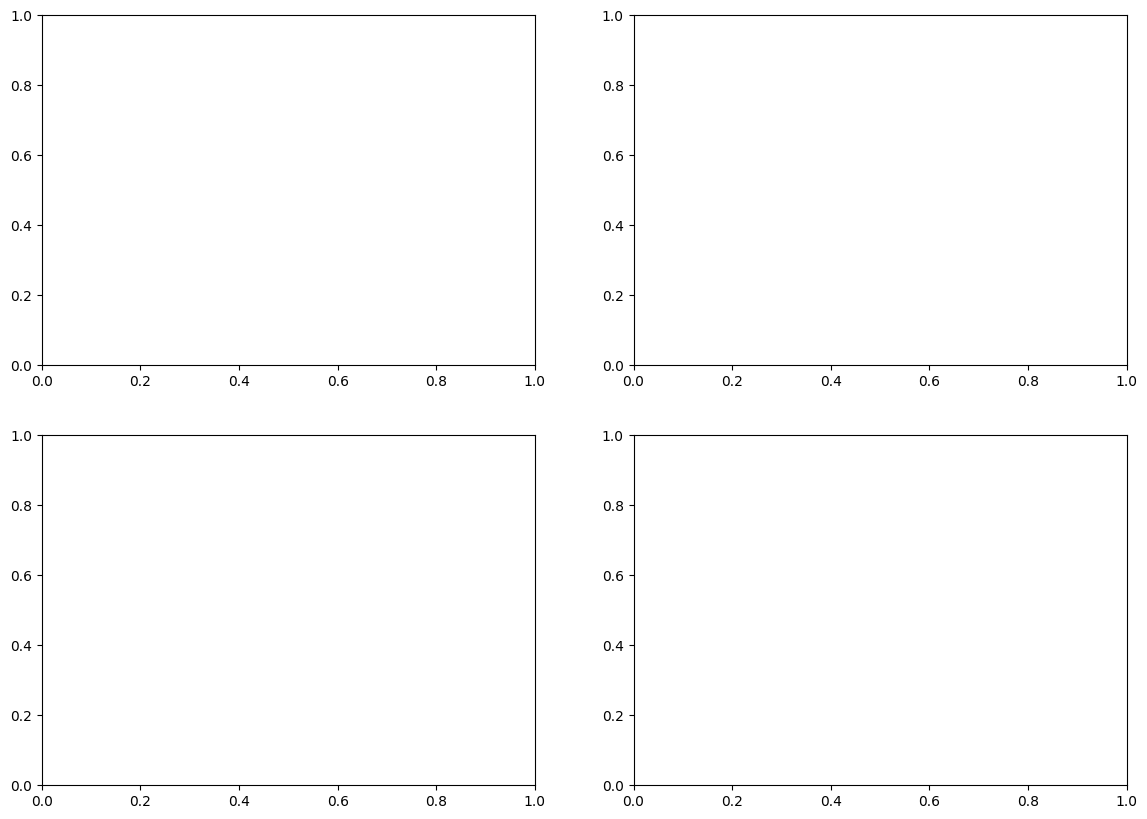

In [ ]:
df.isna().any()

In [29]:
meta_cols = ["true_value", "activity_class"]
score_cols = [c for c in df.columns if c not in meta_cols]
wide = (
    df[score_cols]
    .unstack("docking_tool")  # moves docking_tool into columns
)
wide

CNNscore                                         CNNaffinity  \
docking_tool   diffdock     flexx     gnina    plants     smina    diffdock   
id                                                                            
CHEMBL107472  -0.874603 -0.765289  0.582774 -0.026171  0.381823   -1.095290   
CHEMBL1090364  0.935171 -0.541308  0.574489 -1.157056  0.541017    1.553832   
CHEMBL1095464       NaN -0.825521  1.060590 -0.484878  1.038375         NaN   
CHEMBL1097189 -0.951735  0.710094  1.533824  0.839652  1.460936   -0.992341   
CHEMBL1172773 -1.004356 -1.141631  0.159713 -0.601453  0.012762    0.078200   
...                 ...       ...       ...       ...       ...         ...   
CHEMBL7819    -0.392828  0.036093  1.390605  0.861366  1.218001   -1.174958   
CHEMBL7866    -0.025354  0.074086  1.314042  0.792821  1.199129   -0.655983   
CHEMBL80540   -0.565168 -0.270648  0.886208 -0.704343  0.501047   -0.905427   
CHEMBL92174   -0.673418 -0.695756  1.106845  0.481799  0.702143   -1.297539   
CHEMBL94066   -0.578305 -0.851156  0.802339 -0.130576  0.650683   -1.105783   

                                                       ... vina_hydrophobic  \
docking_tool      flexx     gnina    plants     smina  ...         diffdock   
id                                                     ...                    
CHEMBL107472  -0.967079 -0.270458 -0.652679 -0.343127  ...         0.157800   
CHEMBL1090364  1.132442  1.599651  1.250086  1.566819  ...         1.242926   
CHEMBL1095464 -0.631252  0.615166  0.073201  0.663421  ...              NaN   
CHEMBL1097189  1.109811  1.254737  1.018038  1.239596  ...         0.264112   
CHEMBL1172773 -0.261922  0.818797  0.661294  0.774680  ...         2.563357   
...                 ...       ...       ...       ...  ...              ...   
CHEMBL7819    -1.225440 -0.594183 -0.788753 -0.618691  ...         0.764671   
CHEMBL7866    -0.602795 -0.184641 -0.392353 -0.187243  ...         0.551547   
CHEMBL80540   -0.224691  0.617117  0.445304  0.611157  ...         1.072353   
CHEMBL92174   -1.272158 -0.221253 -0.517932 -0.436096  ...         0.967363   
CHEMBL94066   -0.572683  0.096516  0.067864  0.032985  ...         0.411581   

                                                      vina_intra_hydrophobic  \
docking_tool      flexx     gnina    plants     smina               diffdock   
id                                                                             
CHEMBL107472  -0.934970 -0.728244 -1.083686 -0.805360               0.016371   
CHEMBL1090364 -0.013296  0.038211  0.854696 -0.009163               0.215656   
CHEMBL1095464 -0.264635  0.632677  0.629410  0.632890                    NaN   
CHEMBL1097189  1.451938  2.021907  1.766001  1.951245               0.953191   
CHEMBL1172773  0.291623  1.385698  1.771455  1.336556               2.325126   
...                 ...       ...       ...       ...                    ...   
CHEMBL7819    -0.792865 -0.154733 -0.328012 -0.368364              -0.467417   
CHEMBL7866    -0.539322 -0.385897 -0.490050 -0.444904              -0.462457   
CHEMBL80540   -0.120588  0.428672  0.020464  0.292570              -0.139690   
CHEMBL92174   -1.017876 -0.744385 -0.625223 -0.829516              -0.775052   
CHEMBL94066   -0.104180  0.138354 -0.109907  0.039379              -0.492664   

                                                       
docking_tool      flexx     gnina    plants     smina  
id                                                     
CHEMBL107472  -0.069268 -0.104379 -0.116606 -0.095185  
CHEMBL1090364 -0.098967  0.090766  1.896337  0.011850  
CHEMBL1095464  0.267216  1.109366  0.667901  1.222295  
CHEMBL1097189  2.606673  1.721628  3.365324  1.735982  
CHEMBL1172773  2.545333  2.604300  3.172449  2.241750  
...                 ...       ...       ...       ...  
CHEMBL7819    -0.552980 -0.535669 -0.536412 -0.536283  
CHEMBL7866    -0.564929 -0.535564 -0.535991 -0.535434  
CHEMBL80540   -0.395803 -0.331455 -0.362679 -0.436569  
CHEMBL92

In [30]:
wide.columns = cols = [f"{tool}_{score}" for score, tool in wide.columns]
meta = df[meta_cols].groupby("id").first()
wide = wide.join(meta)